# Source and coverage review

Indonesia only. A/E/B/S labels and source boundaries remain in datasets. These calculations are scenarios, not metered national data-center electricity or water. See docs/methodology.md.

In [1]:
from pathlib import Path
import sys
root = Path.cwd().resolve()
while not (root / 'assumptions.yaml').exists():
    if root == root.parent: raise FileNotFoundError('Run from within the research repository')
    root = root.parent
sys.path.insert(0, str(root / 'src'))
import pandas as pd
from IPython.display import display, Image
from config import read_dataset, assumptions


In [2]:
display(pd.read_csv(root / 'sources.csv')[['source_id','organization','title','quality_tier','geography']])

,source_id,organization,title,quality_tier,geography
0,ELEC001,Ministry of Energy and Mineral Resources (ESDM),Handbook of Energy and Economic Statistics of ...,Tier 1,Indonesia
1,ELEC002,PT PLN (Persero),Penetapan Penyesuaian Tarif Tenaga Listrik Jul...,Tier 1,Indonesia
2,ELEC003,PT PLN (Persero); Ministry of Energy and Miner...,Rencana Usaha Penyediaan Tenaga Listrik 2025-2034,Tier 1,Indonesia
3,ELEC004,Cushman & Wakefield,APAC Data Centre Development Pipeline Hits Rec...,Tier 2,"Greater Jakarta, Indonesia"
4,ELEC005,Ministry of Communication and Digital Affairs ...,Indonesia Kejar Posisi Ekonomi Digital Terbesa...,Tier 1,Indonesia
...,...,...,...,...,...
75,WB026,NVIDIA,NVIDIA Contributes NVIDIA GB200 NVL72 Designs ...,Tier 1,Global
76,WB027,NVIDIA,Blackwell Ultra Datacenter Product Lineup data...,Tier 1,Global
77,WB028,Perumdam Tirta Bhagasasi Bekasi,Perda SPAM dan Dukungan Bupati Jadi Kunci Peng...,Tier 1,Bekasi
78,WB029,Air Batam Hilir,Tarif pelanggan,Tier 1,Batam


In [3]:
projects = read_dataset('datacenter_projects')
display(projects[['company','facility','status','operational_mw','planned_mw','capacity_basis','include_in_inventory','source_id','data_class']])
display(projects.isna().sum().to_frame('missing_count'))

,company,facility,status,operational_mw,planned_mw,capacity_basis,include_in_inventory,source_id,data_class
0,DCI Indonesia,"H1 Campus (JK1, JK2, JK3, JK5, JK6)",operational,75.0,NaN,IT,True,DC001,A
1,DCI Indonesia / Salim Group DISM,"H2 Campus (H2-01, H2-02)",operational,30.0,NaN,IT,True,DC001,A
2,DCI Indonesia,E1,operational,19.0,NaN,IT,True,DC001,A
3,DCI Indonesia,E2,operational,9.0,NaN,IT,True,DC001,A
4,DCI Indonesia,H5 Sky Bintan Data Center Park,planned,NaN,1000.0,IT,True,DC001,A
...,...,...,...,...,...,...,...,...,...
62,BW Digital,NDP1,planned,NaN,120.0,IT,True,DC036,A
63,BW Digital,NDP1 alternative corporate design,planned,NaN,NaN,IT,False,DC037,A
64,SOS Limited / Future Digital Trading,Galang Batang AI/cloud campus,potential,NaN,NaN,undisclosed,True,DC038,A
65,Gaw Capital / Sinar Primera,Golden Digital Gateway phase1,operational,NaN,NaN,undisclosed,True,DC039,A


,missing_count
company,0
facility,0
location,0
province,0
status,0
operational_mw,53
under_construction_mw,61
committed_mw,66
planned_mw,60
potential_mw,64


In [4]:
display(read_dataset('indonesia_electricity'))
from validate_data import validate
issues = validate()
display(pd.DataFrame(issues))

,year,electricity_generation_twh,electricity_consumption_twh,pln_sales_twh,installed_capacity_gw,peak_demand_gw,coal_share_pct,gas_share_pct,hydro_share_pct,geothermal_share_pct,...,diesel_share_pct,mix_formula,gas_share_pct_data_class,hydro_share_pct_data_class,geothermal_share_pct_data_class,solar_share_pct_data_class,other_renewables_pct_data_class,other_renewables_share_pct_data_class,steam_share_pct_data_class,diesel_share_pct_data_class
0,2020,291.831,292.953,243.583,72.76677,41.761,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2021,309.076,314.123,257.634,74.55689,42.785,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2022,333.537,340.642,273.761,83.84283,42.814,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2023,350.609,369.722,288.436,91.20303,58.282,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2024,371.572,409.605,306.219,100.64877,61.288,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2025,494.353,455.001,317.692,107.49889,65.134,NaN,14.191074,6.21742,3.588529,...,2.315147,Sum matching PLN own + PLN purchases + IUPTLS/...,E,E,E,E,E,E,E,E


Validation: 0 errors, 14 warnings (see outputs/validation.log)


,level,dataset,message
0,WARNING,market_anchors,Missing values retained: observation_period=13...
1,WARNING,datacenter_projects,"Missing values retained: operational_mw=53, un..."
2,WARNING,datacenter_projects,Operator announcements overlap and are not a c...
3,WARNING,indonesia_electricity,"Missing values retained: coal_share_pct=6, gas..."
4,WARNING,indonesia_electricity,"Generation, national electricity consumption a..."
5,WARNING,electricity_tariffs,"Missing values retained: tariff_rp_per_kwh=3, ..."
6,WARNING,electricity_tariffs,"Published rates may exclude contract premiums,..."
7,WARNING,water_tariffs,"Missing values retained: consumption_band=2, t..."
8,WARNING,water_tariffs,"Published rates may exclude contract premiums,..."
9,WARNING,climate,"Missing values retained: month=3, avg_temperat..."


,location,year,month,avg_temperature_c,avg_relative_humidity_pct,rainfall_mm,wet_bulb_c,source_id,data_class,station,measurement_status,source_locator,notes
0,Batam,2024,1.0,27.00,86.00,453.5,NaN,WB006,A,Hang Nadim,actual_station_observation,Tables1.2.1/1.2.2/1.2.5; printed pp20/21/24,BMKG station observations reproduced by BPS. N...
1,Batam,2024,2.0,28.20,80.00,163.6,NaN,WB006,A,Hang Nadim,actual_station_observation,Tables1.2.1/1.2.2/1.2.5; printed pp20/21/24,BMKG station observations reproduced by BPS. N...
2,Batam,2024,3.0,28.80,79.00,220.5,NaN,WB006,A,Hang Nadim,actual_station_observation,Tables1.2.1/1.2.2/1.2.5; printed pp20/21/24,BMKG station observations reproduced by BPS. N...
3,Batam,2024,4.0,28.90,82.10,209.7,NaN,WB006,A,Hang Nadim,actual_station_observation,Tables1.2.1/1.2.2/1.2.5; printed pp20/21/24,BMKG station observations reproduced by BPS. N...
4,Batam,2024,5.0,28.20,87.30,363.6,NaN,WB006,A,Hang Nadim,actual_station_observation,Tables1.2.1/1.2.2/1.2.5; printed pp20/21/24,BMKG station observations reproduced by BPS. N...
5,Batam,2024,6.0,27.90,85.50,271.7,NaN,WB006,A,Hang Nadim,actual_station_observation,Tables1.2.1/1.2.2/1.2.5; printed pp20/21/24,BMKG station observations reproduced by BPS. N...
6,Batam,2024,7.0,28.70,81.00,101.3,NaN,WB006,A,Hang Nadim,actual_station_observation,Tables1.2.1/1.2.2/1.2.5; printed pp20/21/24,BMKG station observations reproduced by BPS. N...
7,Batam,2024,8.0,27.90,83.70,253.2,NaN,WB006,A,Hang Nadim,actual_station_observation,Tables1.2.1/1.2.2/1.2.5; printed pp20/21/24,BMKG station observations reproduced by BPS. N...
8,Batam,2024,9.0,28.00,84.00,239.8,NaN,WB006,A,Hang Nadim,actual_station_observation,Tables1.2.1/1.2.2/1.2.5; printed pp20/21/24,BMKG station observations reproduced by BPS. N...
9,Batam,2024,10.0,28.10,84.30,130.6,NaN,WB006,A,Hang Nadim,actual_station_observation,Tables1.2.1/1.2.2/1.2.5; printed pp20/21/24,BMKG station observations reproduced by BPS. N...


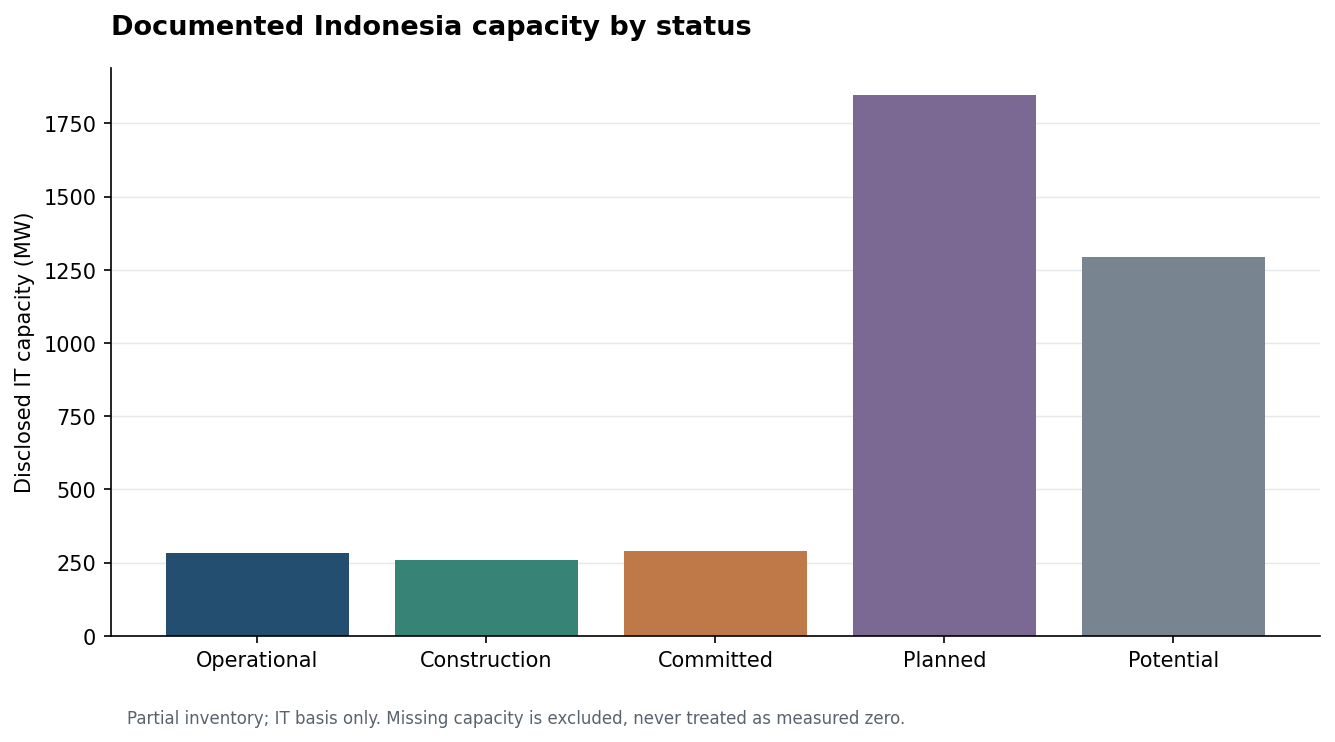

In [5]:
display(read_dataset('climate'))
display(Image(filename=str(root / 'outputs/charts/01_capacity_by_status.png')))